# Multi-modal RAG with LangChain

## Extract the data

Extract the elements of the PDF that we will be able to use in the retrieval process. These elements can be: Text, Images, Tables, etc.

### Partition PDF tables, text, and images

In [1]:
from unstructured.partition.pdf import partition_pdf

output_path = "../data/raw/"
file_path = output_path + 'AI Engineering.pdf'

# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            # extract tables
    strategy="hi_res",                     # mandatory to infer tables

    extract_image_block_types=["Image"],   # Add 'Table' to list to extract image of tables
    # image_output_dir_path=output_path,   # if None, images and tables will saved in base64

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,

    # extract_images_in_pdf=True,          # deprecated
)

No languages specified, defaulting to English.


Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

In [2]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.Table'>"}

In [3]:
# Each CompositeElement containes a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

chunks[3].metadata.orig_elements

In [4]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True
for i, chunk in enumerate(chunks):
    elements = chunk.metadata.orig_elements
    images = [el for el in elements if 'Image' in str(type(el))]
    if images:
        print(i, len(images))

0 3
18 1
19 3
20 1
22 2
23 2
26 1
27 2
28 1
29 1
30 1
35 2
36 1
39 1
48 1
49 2
50 2
68 2
69 1
71 1
72 2
73 1
74 1
76 1
77 1
81 3
82 1
84 2
85 3
86 1
92 1
94 2
95 3
96 1
97 2
99 1
100 1
101 2
103 1
104 2
105 1
108 3
110 1
114 1
117 1
118 1
119 1
122 1
123 1
126 1
127 1
132 1
134 1
135 1
148 1
149 1
151 2
152 1
157 1
158 1
159 1
163 1
164 1
165 2
167 2
172 1
176 1
177 1
184 1
189 2
192 2
193 3
195 1
206 1
209 3
213 2
215 2
216 1
217 2
218 1
221 1
222 1
223 2
224 1
228 1
233 1
234 1
235 1
238 2
239 1
243 2
246 3
247 2
248 3
251 1
255 1
256 1
260 1
262 1
264 1
265 1
266 1
267 1
268 1
270 1
274 3
275 2
276 2
277 1
280 1
285 1
286 4
287 1
288 3
297 1
298 3
299 2
310 1
314 1
315 3
323 1
324 2
325 1
327 1
330 1
332 1
335 1
337 1
340 2
341 3
342 1
344 3
345 1
347 2
349 1
350 1
351 1
353 1
354 1
355 3
356 1
357 1
358 2
361 1
362 1
364 1
366 1
367 2
368 2
369 3
371 1
385 1
386 1


In [5]:
elements = chunks[3].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]

if chunk_images:
    result = chunk_images[0].to_dict()
else:
    print("No images in this chunk")
    result = None

No images in this chunk


### Separate extracted elements into tables, text, and images

In [6]:
# separate tables from texts
tables = []
texts = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)

## 2.2 Chunking Strategy

**Strategy used:** section/semantic-based chunking via `unstructured`'s `chunking_strategy="by_title"`, rather
than a fixed-size sliding window. Elements are grouped by their detected section headings, which keeps a table,
a figure, and its surrounding explanation together in one chunk instead of splitting them at an arbitrary
character offset.

**Parameters and justification:**
- `max_characters=10000` — hard ceiling per chunk. Large enough that a full section (e.g. a page-long
  explanation of an architecture) usually survives intact, small enough to stay within the embedding model's
  effective context and keep retrieval precise (a 10k-character chunk is roughly 1,500–2,000 tokens).
- `combine_text_under_n_chars=2000` — short sections (e.g. a one-line heading followed by a short paragraph)
  are merged with neighboring content so we don't end up with many near-empty, low-signal chunks that would
  dilute retrieval.
- `new_after_n_chars=6000` — once a combined section passes ~6k characters, a new chunk is started proactively
  even if the next heading hasn't been reached yet, avoiding chunks that grow all the way to the 10k hard limit
  and lose topical focus.

This section-based approach was chosen over fixed-size + overlap chunking because the source PDF has clear
headings/structure; a title-aware split preserves semantic coherence per chunk, which matters more for
retrieval quality here than the simplicity of fixed windows.


In [7]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

#### Check what the images look like

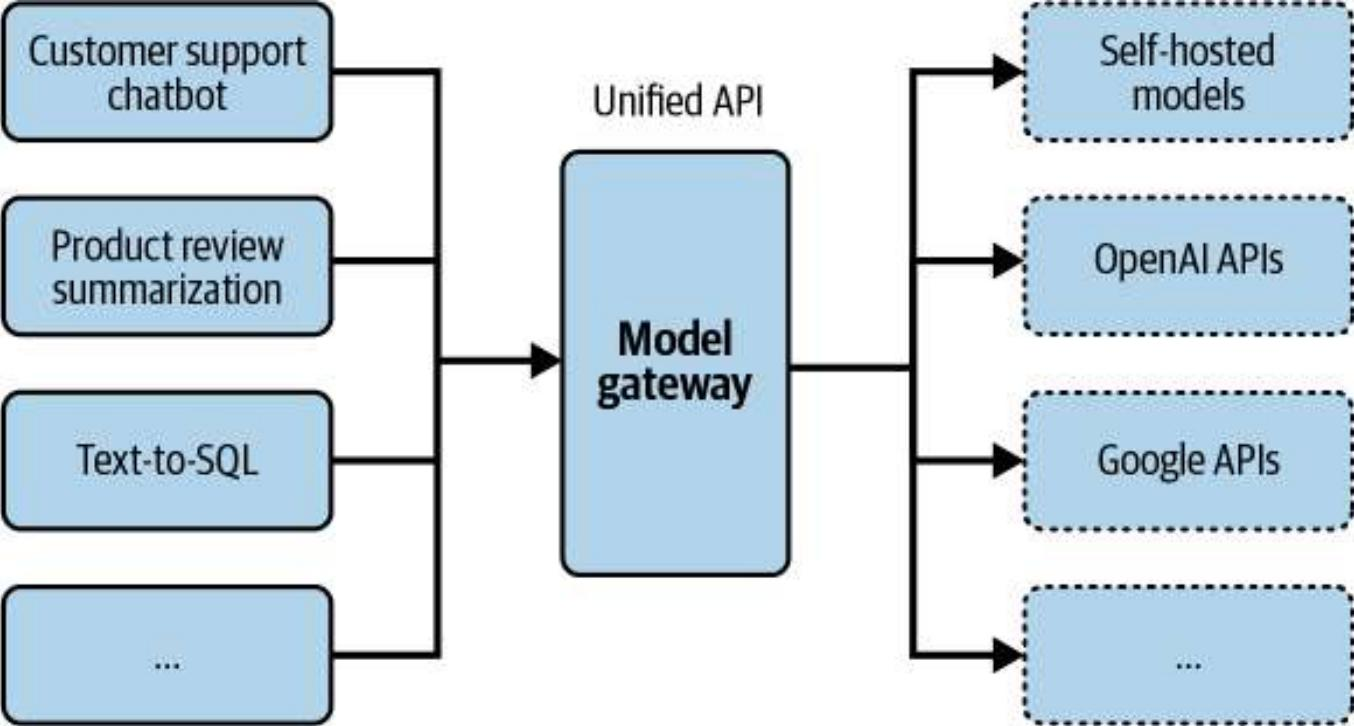

In [8]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[205])

## Summarize the data

Create a summary of each element extracted from the PDF. This summary will be vectorized and used in the retrieval process.

### Text and Table summaries

We don't need a multimodal model to generate the summaries of the tables and the text. I will use open source models available on Groq.

In [9]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [10]:
# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
model = ChatOllama(temperature=0.5, model="llama3.2:3b ")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [11]:
# Summarize text
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 3})

# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html, {"max_concurrency": 3})

In [12]:
text_summaries

['This book, AI Engineering, by Chip Huyen, is a comprehensive guide to building generative AI systems using foundation models, offering a holistic approach to navigating the AI landscape and developing practical applications.',
 'This book offers a comprehensive guide to building generative AI systems, covering essential aspects such as model development, evaluation, and deployment, making it a must-read for professionals and a vital resource for anyone involved in AI development.',
 'Summary of the provided text:\n\nA book titled "AI Engineering" by Chip Huyen, published by O\'Reilly Media, Inc., covering AI engineering, including building applications with foundation models.',
 "Table of Contents for the First Edition of the book, published by O'Reilly Media, Inc.",
 'No summary provided, as no table or text was given.',
 'Table: 3. Evaluation Methodology\n\nModels can act as judges in comparative evaluation, but challenges arise, including defining evaluation metrics, addressing bi

### Image summaries

We will use gpt-4o-mini to produce the image summaries.

In [13]:
# Build (image_b64, surrounding_text, page_number) tuples
def get_images_with_context(chunks):
    items = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_text = chunk.text
            page_num = getattr(chunk.metadata, "page_number", None)
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    items.append({
                        "image": el.metadata.image_base64,
                        "context_text": chunk_text[:1500],
                        "page_number": page_num,
                    })
    return items

image_items = get_images_with_context(chunks)

In [19]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

caption_prompt_template = """You are captioning a figure from a research book/paper for a retrieval system.
Surrounding text on this page (for context — use it to identify what the figure depicts, but don't invent details you can't see):
{context_text}

Describe this specific image so it can be distinguished from other images in the same document:
- If it is a chart/plot: name the exact chart type, axis labels, units, and legend categories you can actually read.
- If it is a diagram: name the components and how they connect (e.g. "encoder block feeding into...").
- If it is a photo, screenshot, or table-like image: say what it literally shows.
- Include any caption/figure number text visible in the image, verbatim if legible.
- Do NOT generalize ("a diagram related to transformers") — be specific enough that this description would not match a different figure in the same book.
If you cannot clearly make out details, say so explicitly rather than guessing.

Respond with only the description, no preamble."""

messages = [
    (
        "user",
        [
            {"type": "text", "text": "{prompt_text}"},
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,{image}"},
            },
        ],
    )
]

img_prompt = ChatPromptTemplate.from_messages(messages)
caption_model = ChatOllama(model="qwen2.5vl:7b", temperature=0,num_ctx=8192)
chain = img_prompt | caption_model | StrOutputParser()

image_summaries = []
for i, item in enumerate(image_items):
    summary = chain.invoke({
        "prompt_text": caption_prompt_template.format(context_text=item["context_text"]),
        "image": item["image"],
    })
    image_summaries.append(summary)
    print(f"[{i+1}/{len(image_items)}] captioned")

[1/226] captioned
[2/226] captioned
[3/226] captioned
[4/226] captioned
[5/226] captioned
[6/226] captioned
[7/226] captioned
[8/226] captioned
[9/226] captioned
[10/226] captioned
[11/226] captioned
[12/226] captioned
[13/226] captioned
[14/226] captioned
[15/226] captioned
[16/226] captioned
[17/226] captioned
[18/226] captioned
[19/226] captioned
[20/226] captioned
[21/226] captioned
[22/226] captioned
[23/226] captioned
[24/226] captioned
[25/226] captioned
[26/226] captioned
[27/226] captioned
[28/226] captioned
[29/226] captioned
[30/226] captioned
[31/226] captioned
[32/226] captioned
[33/226] captioned
[34/226] captioned
[35/226] captioned
[36/226] captioned
[37/226] captioned
[38/226] captioned
[39/226] captioned
[40/226] captioned
[41/226] captioned
[42/226] captioned
[43/226] captioned
[44/226] captioned
[45/226] captioned
[46/226] captioned
[47/226] captioned
[48/226] captioned
[49/226] captioned
[50/226] captioned
[51/226] captioned
[52/226] captioned
[53/226] captioned
[5

In [20]:
image_summaries

['The image shows a large black letter "A" on a white background. There is no additional text or diagrammatic elements visible in the image. The figure number "9" is visible in the top right corner of the image.',
 'The image is a cover illustration of a book titled "AI Engineering: Building Applications with Foundation Models" by Chip Huyen. The illustration features a detailed drawing of an owl perched on a branch. The owl is depicted with intricate feather patterns and a sharp, focused gaze. The branch is textured and covered with small patches of green moss. The background is plain white, and the title and author\'s name are written in a clean, sans-serif font at the top and bottom of the cover, respectively. The figure number "9" is visible in the bottom right corner.',
 'The image shows a barcode with the numbers "781098166304" on the left and "57999" on the right. The barcode is a standard EAN-13 barcode, which is commonly used for product identification in retail. The numbers a

In [21]:
print(image_summaries[1])

The image is a cover illustration of a book titled "AI Engineering: Building Applications with Foundation Models" by Chip Huyen. The illustration features a detailed drawing of an owl perched on a branch. The owl is depicted with intricate feather patterns and a sharp, focused gaze. The branch is textured and covered with small patches of green moss. The background is plain white, and the title and author's name are written in a clean, sans-serif font at the top and bottom of the cover, respectively. The figure number "9" is visible in the bottom right corner.


## Load data and summaries to vectorstore

### Create the vectorstore

In [22]:
import uuid
from langchain_classic.vectorstores import Chroma
from langchain_classic.storage import InMemoryStore
from langchain_classic.schema.document import Document
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_ollama import OllamaEmbeddings
from pathlib import Path

# The vectorstore to use to index the child chunks
embeddings = OllamaEmbeddings(model="nomic-embed-text")

# 3. Pass the Ollama embeddings to Chroma

RAG_DIR = Path("../data/rag_export")
CHROMA_DIR = RAG_DIR / "chroma"
RAG_DIR.mkdir(parents=True, exist_ok=True)

vectorstore = Chroma(
    collection_name="multi_modal_rag_v2",   # <-- changed name
    embedding_function=embeddings,
    persist_directory=str(CHROMA_DIR),
)

store = InMemoryStore()
id_key = "doc_id"

# 5. The retriever (remains unchanged)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

C:\Users\HYH\AppData\Local\Temp\ipykernel_27588\2798470127.py:18: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


### Load the summaries and link the to the original data

In [23]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids, texts)))

# Add tables
table_ids = [str(uuid.uuid4()) for _ in tables]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
]
retriever.vectorstore.add_documents(summary_tables)
retriever.docstore.mset(list(zip(table_ids, tables)))

# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in image_items]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]})
    for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(list(zip(img_ids, [item["image"] for item in image_items])))

### Check retrieval

In [24]:
# Retrieve
docs = retriever.invoke(
    "who are the authors of the paper?"
)

In [25]:
for doc in docs:
    print(str(doc) + "\n\n" + "-" * 80)

Group Occupations with highest exposure % Exposure Human α Interpreters and translators 76.5 Survey researchers 75.0 Poets, lyricists, and creative writers 68.8 Animal scientists 66.7 Public relations specialists 66.7 Human β Survey researchers 84.4 Writers and authors 82.5 Interpreters and translators 82.4 Public relations specialists 80.6 Animal scientists 77.8 Human ζ Mathematicians 100.0 Tax preparers 100.0 Financial quantitative analysts 100.0 Writers and authors 100.0 Web and digital interface designers 100.0 Humans labeled 15 occupations as “fully exposed”.

--------------------------------------------------------------------------------
Acquisitions Editor: Nicole Butterfield Indexer: WordCo Indexing Services, Inc. Development Editor: Melissa Potter Interior Designer: David Futato Production Editor: Beth Kelly Cover Designer: Karen Montgomery Copyeditor: Liz Wheeler Illustrator: Kate Dullea

--------------------------------------------------------------------------------
U

uns

## RAG pipeline

In [31]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_ollama import ChatOllama
from base64 import b64decode


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {"images": b64, "texts": text}


def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element.text

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{image}"},
                }
            )

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatOllama(model="qwen2.5vl:7b ", temperature=0.5, num_ctx=8192)
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOllama(model="qwen2.5vl:7b", temperature=0.5, num_ctx=8192)
        | StrOutputParser()
    )
)

In [32]:
response = chain.invoke(
    "What is the attention mechanism?"
)

print(response)

The attention mechanism is a component of neural network models, particularly in transformer architectures, that allows the model to focus on specific parts of the input data when generating output. It is designed to improve the model's ability to handle long sequences and to capture dependencies between different parts of the sequence.

In the context of natural language processing, the attention mechanism is used to compute the relevance of each word in the input sequence to the current token being predicted. This is done by computing a weighted sum of the hidden states of the input sequence, where the weights are determined by the similarity between the current query vector (which represents the current token being predicted) and the key and value vectors of each word in the input sequence. The attention mechanism thus allows the model to "focus" on the most relevant parts of the input sequence when generating the output.


Response: The RAG (Retrieval-Augmented Generation) architecture is a system that combines a retriever and a generative model to generate responses to queries. Here's a breakdown of the RAG architecture as described in the context:

1. **External Memory**: This is the source of data where the retriever can access information. It can include various types of data such as documents, tables, chat history, etc.

2. **Retriever**: The retriever is responsible for retrieving information from the external memory that is relevant to the query. It performs indexing and querying. Indexing involves processing the data so it can be quickly retrieved later, and querying involves sending a query to retrieve the relevant data.

3. **Generative Model**: This model takes the context information retrieved by the retriever and generates a response. The response is typically the final output of the system.

4. **Prompt**: This is the input to the RAG system, which is the user's query or prompt. The retriev

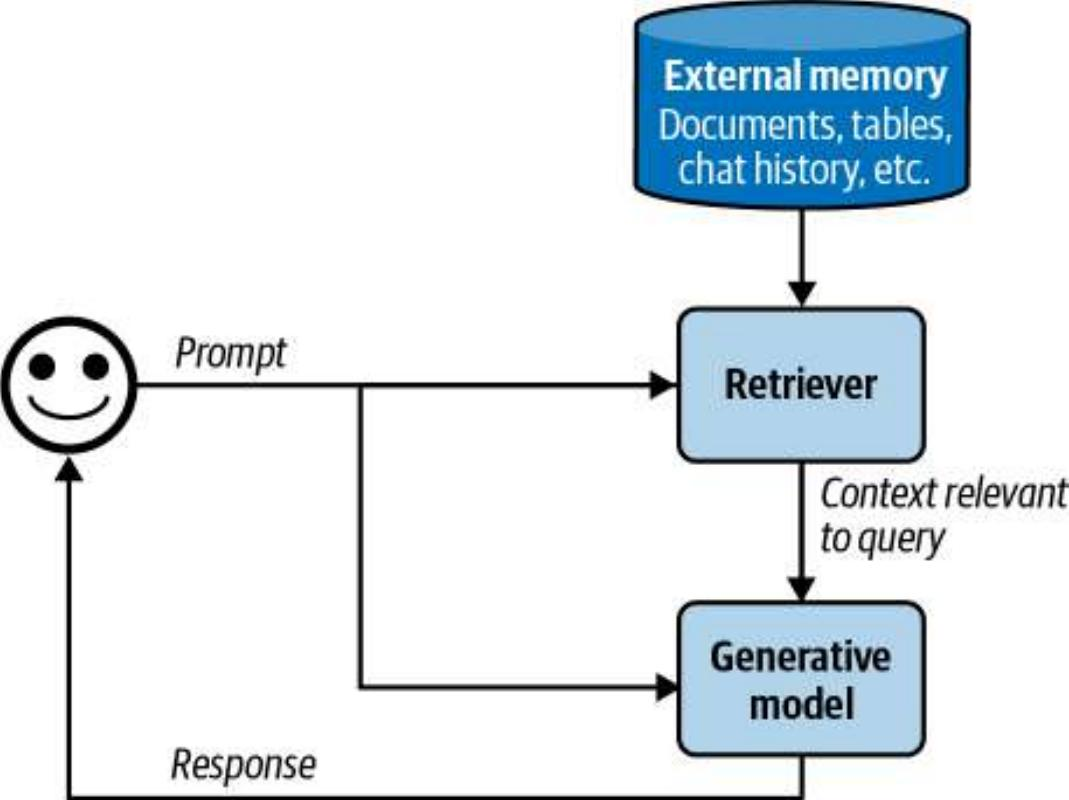

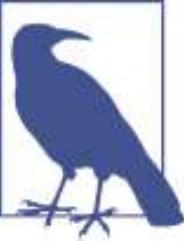

In [33]:
response = chain_with_sources.invoke(
    "What is RAG architecture?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text.text)
    print("Page number: ", text.metadata.page_number)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)

## 2.4 Retrieval & Prompting — Testing Against 10 Sample Questions

Run the retrieval function against at least 10 sample questions to check that relevant chunks come back before
relying on it inside the full RAG chain.


In [34]:
# 2.4 Retrieval & Prompting — test retrieval against 10 sample questions
sample_questions = [
    "who are the authors of the Book?",
    "What is the attention mechanism?",
    "What is RAG architecture?",
    "What is a transformer model?",
    "How does self-attention differ from cross-attention?",
    "What datasets were used for evaluation?",
    "What are the main contributions of this paper?",
    "How is positional encoding computed?",
    "What are the limitations mentioned in the paper?",
    "How does the model handle multi-head attention?",
]

retrieval_results = []
for q in sample_questions:
    docs = retriever.invoke(q)
    retrieval_results.append({"question": q, "n_docs_retrieved": len(docs), "docs": docs})
    print(f"Q: {q}")
    print(f"  -> retrieved {len(docs)} chunk(s)")


Q: who are the authors of the Book?
  -> retrieved 4 chunk(s)
Q: What is the attention mechanism?
  -> retrieved 4 chunk(s)
Q: What is RAG architecture?
  -> retrieved 4 chunk(s)
Q: What is a transformer model?
  -> retrieved 4 chunk(s)
Q: How does self-attention differ from cross-attention?
  -> retrieved 4 chunk(s)
Q: What datasets were used for evaluation?
  -> retrieved 4 chunk(s)
Q: What are the main contributions of this paper?
  -> retrieved 4 chunk(s)
Q: How is positional encoding computed?
  -> retrieved 4 chunk(s)
Q: What are the limitations mentioned in the paper?
  -> retrieved 4 chunk(s)
Q: How does the model handle multi-head attention?
  -> retrieved 4 chunk(s)


## 2.6 Evaluation

Run the full RAG chain (retrieval + prompting + generation) on the same 10 sample questions, then manually mark
whether each retrieved context was relevant and whether the answer was grounded in that context or hallucinated.


In [35]:
# 2.6 Evaluation — run the RAG chain end-to-end on 10 test questions,
# then use the LLM itself as a judge to score context relevance and groundedness.
import json as _json
import pandas as pd
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

judge_prompt_text = """
You are a strict evaluator for a RAG (Retrieval-Augmented Generation) system.
You will be given a QUESTION, the CONTEXT that was retrieved for it, and the ANSWER the system produced.

Judge two things:
1. context_relevant: was the retrieved CONTEXT actually relevant/sufficient to answer the QUESTION?
   Answer "Yes" or "No".
2. grounded: is the ANSWER fully supported by the CONTEXT (no facts invented beyond it)?
   Answer "Grounded" if every claim in the answer traces back to the context,
   or "Hallucinated" if the answer adds information not present in the context.

Respond with ONLY a JSON object, no other text, no markdown fences, in exactly this shape:
{{"context_relevant": "Yes" or "No", "grounded": "Grounded" or "Hallucinated", "reasoning": "<one short sentence>"}}

QUESTION: {question}

CONTEXT:
{context}

ANSWER: {answer}
"""
judge_prompt = ChatPromptTemplate.from_template(judge_prompt_text)
judge_model = ChatOllama(model="llama3.2:3b", temperature=0)
judge_chain = judge_prompt | judge_model | StrOutputParser()


def judge_answer(question, context_text, answer):
    """Ask the LLM to score context relevance and groundedness; fall back gracefully if it doesn't return clean JSON."""
    raw = judge_chain.invoke({"question": question, "context": context_text, "answer": answer})
    cleaned = raw.strip().strip("`")
    if cleaned.lower().startswith("json"):
        cleaned = cleaned[4:].strip()
    try:
        parsed = _json.loads(cleaned)
        return (
            parsed.get("context_relevant", "Unknown"),
            parsed.get("grounded", "Unknown"),
            parsed.get("reasoning", ""),
        )
    except Exception:
        return "Unknown", "Unknown", raw[:200]


eval_rows = []
for q in sample_questions:
    result = chain_with_sources.invoke(q)
    answer = result["response"]

    sources = []
    context_text_parts = []
    for t in result["context"]["texts"]:
        page = getattr(t.metadata, "page_number", None)
        sources.append(f"page {page}" if page is not None else "text chunk")
        context_text_parts.append(t.text)
    if result["context"]["images"]:
        sources.append(f"{len(result['context']['images'])} image(s)")
        context_text_parts.append(f"[{len(result['context']['images'])} image(s) provided as visual context]")
    source_str = "; ".join(sources) if sources else "no context retrieved"
    context_text = "\n\n".join(context_text_parts) if context_text_parts else "(no text context retrieved)"

    context_relevant, grounded, reasoning = judge_answer(q, context_text, answer)

    eval_rows.append({
        "question": q,
        "retrieved_source": source_str,
        "answer": answer,
        "context_relevant": context_relevant,
        "grounded_or_hallucinated": grounded,
        "judge_reasoning": reasoning,
    })

eval_df = pd.DataFrame(eval_rows)
eval_df


,question,retrieved_source,answer,context_relevant,grounded_or_hallucinated,judge_reasoning
0,who are the authors of the Book?,page 6; page 6; page 5; page 519,The author of the book is Chip Huyen.,Yes,Grounded,"The context provides the author's name, Chip H..."
1,What is the attention mechanism?,page 85; 3 image(s),The attention mechanism is a key component in ...,Yes,Grounded,The context provides a detailed explanation of...
2,What is RAG architecture?,page 278; page 280; 2 image(s),The RAG (Retrieval-Augmented Generation) archi...,Yes,Grounded,The context provides a clear and detailed expl...
3,What is a transformer model?,page 86; page 82; page 88; 1 image(s),A transformer model is a type of neural networ...,Yes,Grounded,"The question asks about a transformer model, w..."
4,How does self-attention differ from cross-atte...,page 85; page 253; 2 image(s),Self-attention and cross-attention are both fo...,Yes,Grounded,The context provides a detailed explanation of...
5,What datasets were used for evaluation?,page 229; page 228; page 231; page 137,The context provided does not explicitly menti...,Yes,Grounded,The context provides specific details about th...
6,What are the main contributions of this paper?,page 66; page 153; page 70; page 9,The main contributions of the paper appear to ...,Yes,Grounded,The answer is grounded because it directly ref...
7,How is positional encoding computed?,page 158; 3 image(s),The context provided does not mention position...,No,Hallucinated,The context does not mention positional encodi...
8,What are the limitations mentioned in the paper?,page 164; page 215; page 532; page 253,The limitations mentioned in the paper include...,Yes,Grounded,The context provides specific examples and lim...
9,How does the model handle multi-head attention?,page 85; page 93; 2 image(s),The model handles multi-head attention by spli...,Yes,Grounded,The context provides a detailed explanation of...


In [36]:
# ============================================================
# FINAL CELL — SAVE THE COMPLETE RAG
# ============================================================
#
# This saves BOTH parts of the MultiVector RAG:
# 1. Chroma child-summary embeddings
# 2. Parent documents/elements used to build the final context
#
# The embedding model and collection configuration are saved too.

from pathlib import Path
import json
import pickle

RAG_DIR = Path("../data/rag_export")
CHROMA_DIR = RAG_DIR / "chroma"
RAG_DIR.mkdir(parents=True, exist_ok=True)

# Chroma is already persistent because it was initialized with
# persist_directory=CHROMA_DIR.
# Keep this call for older Chroma versions that expose persist().
if hasattr(vectorstore, "persist"):
    try:
        vectorstore.persist()
    except Exception:
        pass

# Save the parent store. InMemoryStore keeps its values in .store.
RAG_DIR = Path("../data/rag_export")
CHROMA_DIR = RAG_DIR / "chroma"

with open(RAG_DIR / "parent_store.pkl", "wb") as f:
    pickle.dump(store.store, f)

config = {
    "collection_name": "multi_modal_rag",
    "id_key": id_key,
    "embedding_model": "nomic-embed-text",
    "llm_model": "llava",
    "chroma_directory": "chroma",
    "parent_store_file": "parent_store.pkl",
}
with open(RAG_DIR / "rag_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)


print("RAG SAVED SUCCESSFULLY")
print("Location:", RAG_DIR.resolve())
print()
print("Files:")
for p in sorted(RAG_DIR.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(RAG_DIR))


RAG SAVED SUCCESSFULLY
Location: D:\Honda\ITI-AI2\Project\data\rag_export

Files:
 - chroma\a890d84f-5a6f-4d42-ada0-84ecad16ebb6\data_level0.bin
 - chroma\a890d84f-5a6f-4d42-ada0-84ecad16ebb6\header.bin
 - chroma\a890d84f-5a6f-4d42-ada0-84ecad16ebb6\length.bin
 - chroma\a890d84f-5a6f-4d42-ada0-84ecad16ebb6\link_lists.bin
 - chroma\chroma.sqlite3
 - parent_store.pkl
 - rag_config.json


C:\Users\HYH\AppData\Local\Temp\ipykernel_27588\3502323986.py:24: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectorstore.persist()
